In [3]:
import pandas as pd

df = pd.read_csv('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/all_imgs_clean_80756_total.csv') 
df = df[~df['pose_is_none']]       

In [4]:
from clothing_segmentation import HumanParser
from PIL import Image
human_parser = HumanParser()
img_person = '/mnt/datadrive/asos_dataset/3602/1005/1657.png'
person_image = Image.open(img_person).convert('RGB').resize((768, 768), Image.BICUBIC)
person_image_hp = human_parser.forward_img(person_image).squeeze(0)

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 

In [7]:
img_person = '/mnt/datadrive/asos_dataset/3602/1005/1657.png'
person_image = Image.open(img_person).convert('RGB').resize((768, 768), Image.BICUBIC)
person_image_hp = human_parser.forward_img(person_image).squeeze(0)

NameError: name 'human_parser' is not defined

In [20]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

# url = "https://plus.unsplash.com/premium_photo-1673210886161-bfcc40f54d1f?ixlib=rb-4.0.3&ixid=MnwxMjA3fDB8MHxzZWFyY2h8MXx8cGVyc29uJTIwc3RhbmRpbmd8ZW58MHx8MHx8&w=1000&q=80"

image = Image.open('/mnt/datadrive/asos_dataset/3602/1275/6251.png')
inputs = processor(images=image, return_tensors="pt")

outputs = model(**inputs)
logits = outputs.logits.cpu()

upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

pred_seg = upsampled_logits.argmax(dim=1)[0]
# plt.imshow(pred_seg.isin([2]))


0


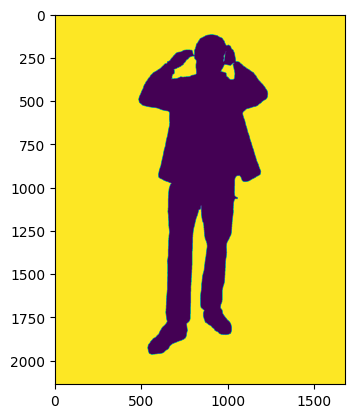

1


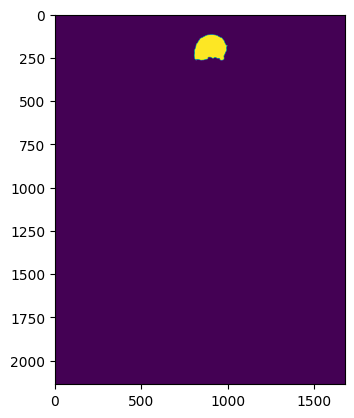

2


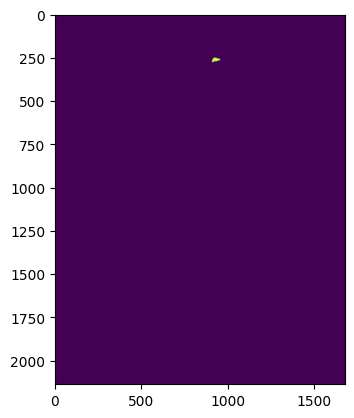

4


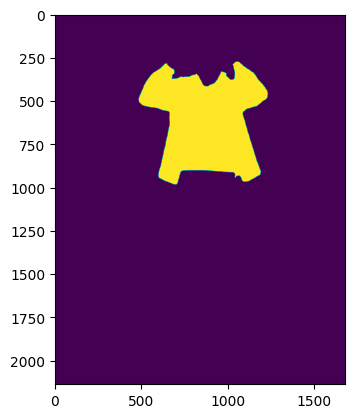

6


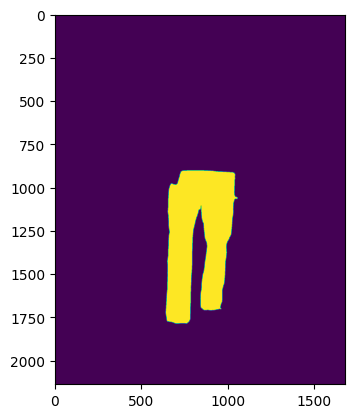

9


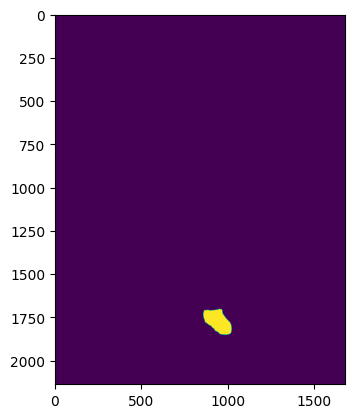

10


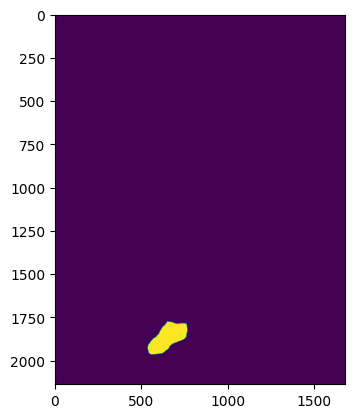

11


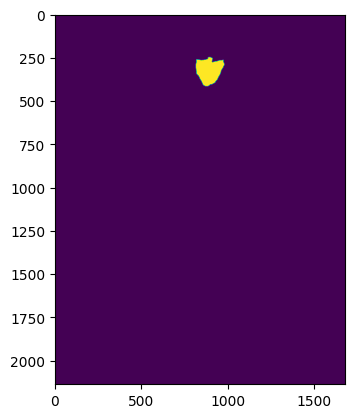

14


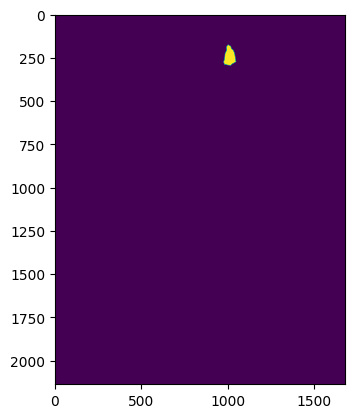

15


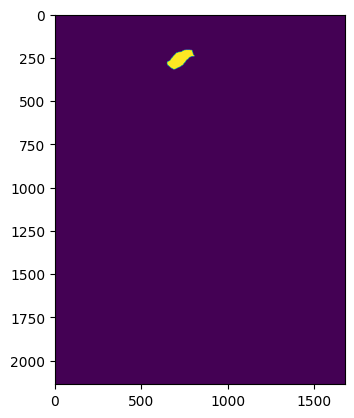

In [21]:
# 4,7

# 15 and 14 and 11
import numpy as np
pred_seg = upsampled_logits.argmax(dim=1)[0]
for i in np.unique(pred_seg):
    print(i)
    plt.imshow(pred_seg==i)
    plt.show()

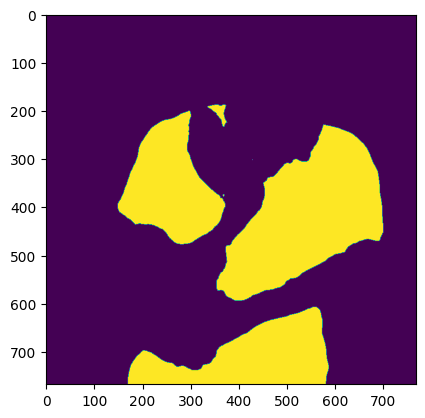

In [8]:
from matplotlib import pyplot as plt
plt.imshow(person_image_hp==7)

In [9]:
head = 2 # + hair

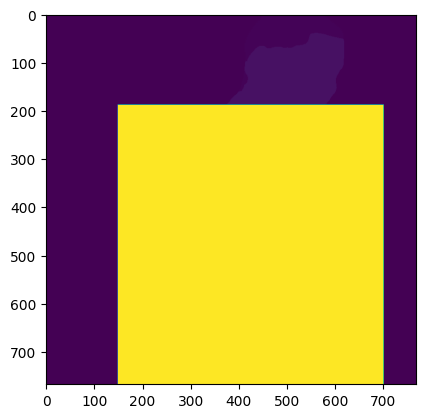

In [44]:
# plt.imshow(person_image_hp==7)
import numpy as np
import cv2


# Find contours in the binary image
contours, hierarchy = cv2.findContours((person_image_hp==7).numpy().astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Create an empty image to draw the bounding rectangles
all_contours = np.vstack(contours)

bounding_rect_image = person_image_hp.numpy().astype(np.uint8).copy()

x, y, w, h = cv2.boundingRect(all_contours)
cv2.rectangle(bounding_rect_image, (x, y), (x + w, y + h), (255, 255, 255), -1)

plt.imshow(bounding_rect_image)
plt.show()

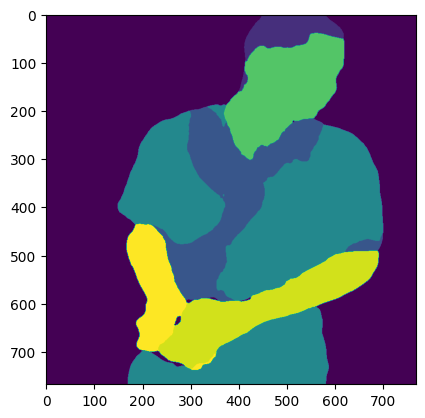

In [11]:
plt.imshow(person_image_hp)

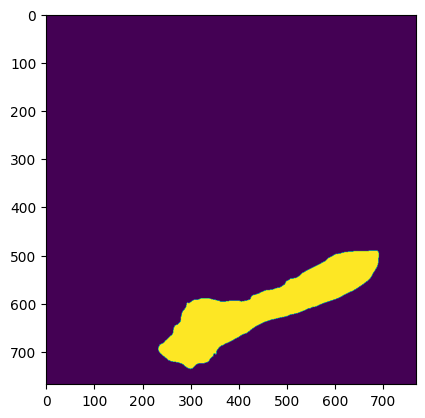

In [12]:
# ruka1 = 15
# ruka2 = 14

plt.imshow(person_image_hp==14)

In [2]:
from tryondiffusion.dataset import MyOpenPoseDetector
from diffusers.utils import load_image

openpose = MyOpenPoseDetector.from_pretrained("lllyasviel/ControlNet")


/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


In [11]:

from tryondiffusion.dataset import MyOpenPoseDetector
from diffusers.utils import load_image

openpose = MyOpenPoseDetector.from_pretrained("lllyasviel/ControlNet")

op_img = load_image(img_person)
person_pose = openpose(op_img, include_hand=True)


In [15]:
person_pose

array([[0.77539062, 0.1921875 ],
       [0.57226562, 0.3578125 ],
       [0.34375   , 0.33125   ],
       [0.2734375 , 0.584375  ],
       [0.30859375, 0.7546875 ],
       [0.80273438, 0.3796875 ],
       [0.83789062, 0.665625  ],
       [0.54882812, 0.80625   ],
       [0.37109375, 0.9296875 ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.63671875, 0.9921875 ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.73632812, 0.146875  ],
       [0.78710938, 0.1515625 ],
       [0.5859375 , 0.115625  ],
       [0.        , 0.        ]])

0 0.775390625 0.1921875


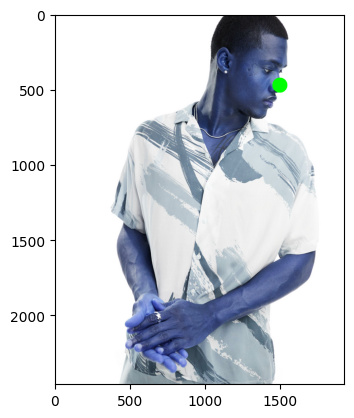

1 0.572265625 0.3578125


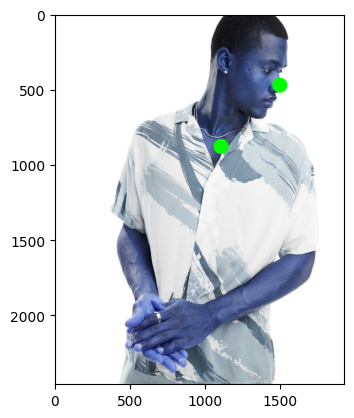

2 0.34375 0.33125


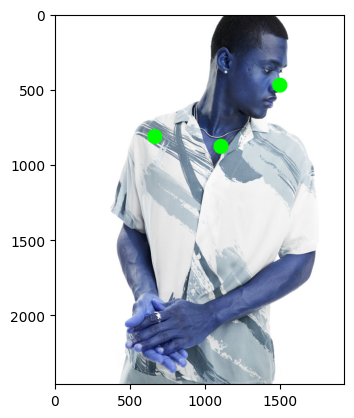

3 0.2734375 0.584375


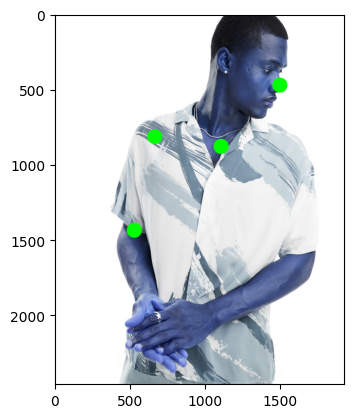

4 0.30859375 0.7546875


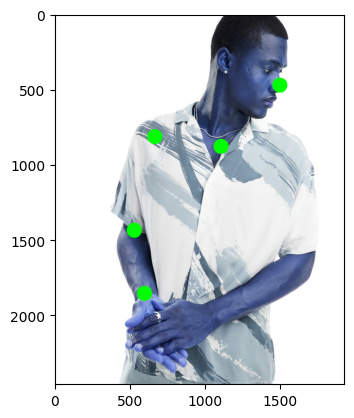

5 0.802734375 0.3796875


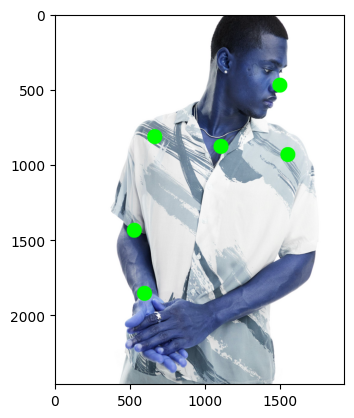

6 0.837890625 0.665625


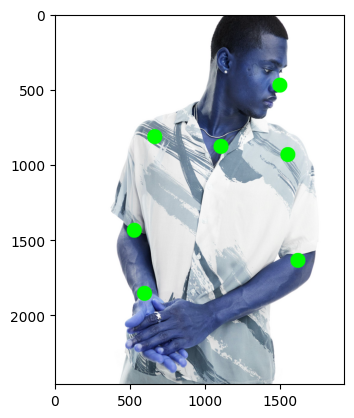

7 0.548828125 0.80625


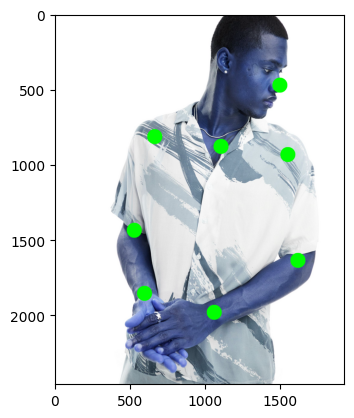

8 0.37109375 0.9296875


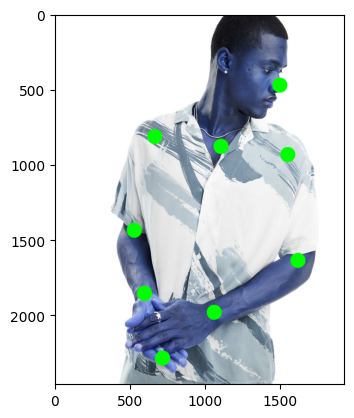

9 0.0 0.0


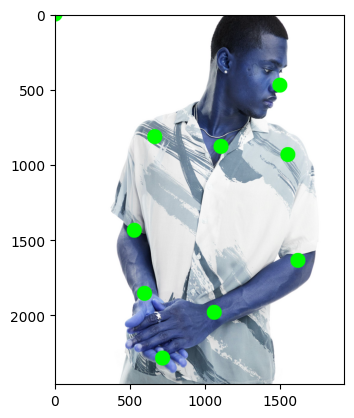

10 0.0 0.0


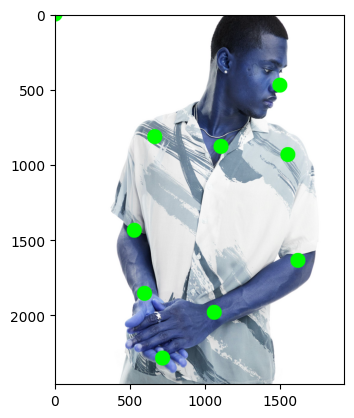

11 0.63671875 0.9921875


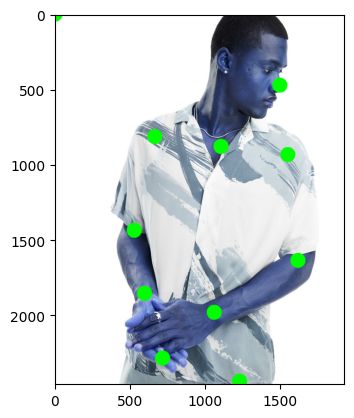

12 0.0 0.0


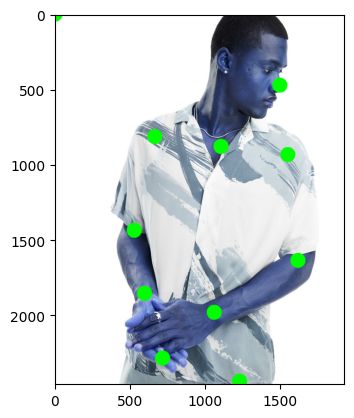

13 0.0 0.0


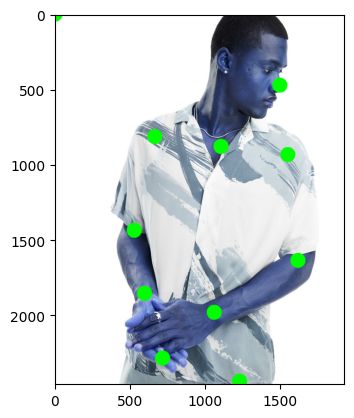

14 0.736328125 0.146875


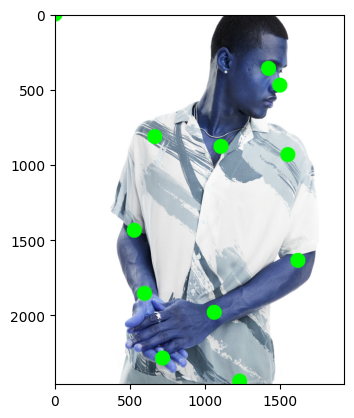

15 0.787109375 0.1515625


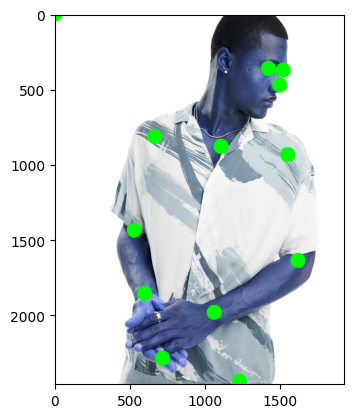

16 0.5859375 0.115625


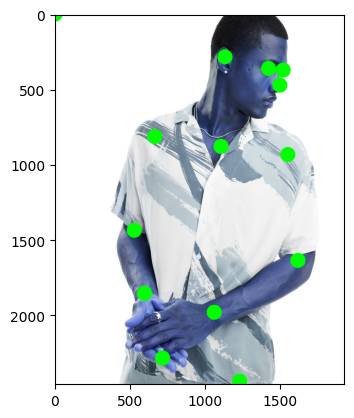

17 0.0 0.0


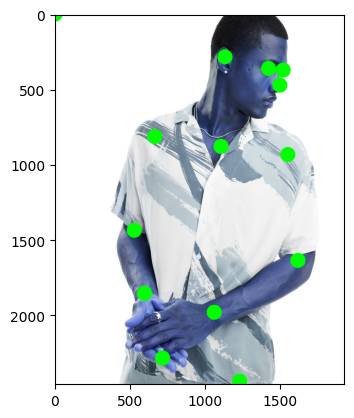

In [14]:
# sheya - toje v masky

# 1 - nachalo sheya 

# 2 - plecho 
# 5 - plecho

# 4, 7 - kisti
# 3, 6 - lokti

# 8 i 11 - bedra, kak budto do nih shmotka dolzhna but
from matplotlib import pyplot as plt

idxs = [4,7, 3,6]

import cv2
img = cv2.imread(img_person)
height, width, c = img.shape
for idx, point in enumerate(person_pose):
    x, y = point
    # if idx in idxs:
    if True:
        print(idx, x, y)
        x = int(x * width)
        y = int(y * height)
        cv2.circle(img, (x, y), 50, (0, 255, 0), -1)  # Draw a green circle
        plt.imshow(img)
        plt.show()


# from tryondiffusion.dataset import MyOpenPoseDetector
# from diffusers.utils import load_image

# openpose = MyOpenPoseDetector.from_pretrained("lllyasviel/ControlNet")

# op_img = load_image(img_person)
# person_pose, right_hand, left_hand = openpose(op_img, include_hand=True)

kist1 = person_pose[4]
lokot1 = person_pose[3]

kist2 = person_pose[7]
lokot2 = person_pose[6]

In [17]:
kist2, lokot2

(array([0.54882812, 0.80625   ]), array([0.83789062, 0.665625  ]))

[[1019 2008]
 [ 914 1962]
 [ 831 1916]
 [ 631 1997]
 [ 789 2050]
 [ 665 2081]
 [ 789 2365]
 [ 718 2143]
 [ 797 2277]
 [ 857 2331]
 [ 868 2158]
 [ 797 2196]
 [ 861 2258]
 [ 545 2020]
 [ 665 2089]
 [ 789 2358]
 [ 710 2143]
 [ 853 2331]
 [ 797 2196]]


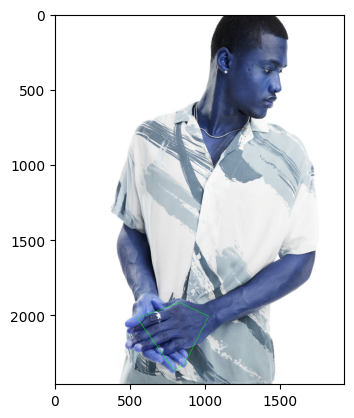

In [18]:
import cv2
import numpy as np

img = cv2.imread(img_person)

right_hand_m = np.vstack((left_hand, right_hand))
right_hand_m = np.array([(int(x*width),int(y*height)) for x,y in right_hand_m if x > 0])
print(right_hand_m)


binary_image = np.zeros((height, width), dtype=np.uint8)

# Create a blank image
binary_image = np.zeros((height, width), dtype=np.uint8)

# Calculate the convex hull of the hand keypoints
hull = cv2.convexHull(right_hand_m)

# Draw the convex hull on the binary image
cv2.polylines(binary_image, [hull], isClosed=True, color=255, thickness=2)

hull_image = np.zeros((height, width, 3), dtype=np.uint8)

# Draw the convex hull
cv2.polylines(img, [hull], isClosed=True, color=(0, 255, 0), thickness=2)
plt.imshow(img)

In [19]:
person_image_hp.shape

torch.Size([768, 768])

(399, 574) (442, 663)


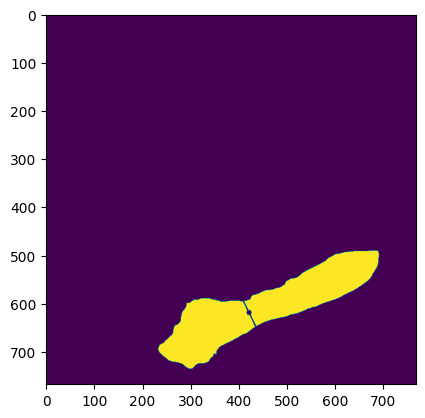

In [20]:
import cv2
import numpy as np

# Coordinates of the elbow and wrist
x_e, y_e = lokot2
x_w, y_w = kist2
elbow = (int(x_e*768), int(y_e*768))
wrist = (int(x_w*768), int(y_w*768))

x_e, y_e = elbow
x_w, y_w = wrist
# print(elbow, wrist)

# Create a blank image
# image = np.zeros((height, width, 3), dtype=np.uint8)
image = (person_image_hp==14).numpy().astype(np.uint8)
arm_mask = (person_image_hp==14).numpy().astype(np.uint8)
# Draw the elbow and wrist points
cv2.circle(image, elbow, 5, (1, 0, 0), -1)  # Blue circle for elbow
cv2.circle(image, wrist, 5, (0, 1, 0), -1)  # Green circle for wrist

# x_e, y_e = elbow
# x_w, y_w = wrist

vector = np.array([x_w - x_e, y_w - y_e])
perpendicular_vector = np.array([-vector[1], vector[0]])
# Draw the vector from elbow to wrist
# cv2.arrowedLine(image, elbow, wrist, (0, 0, 1), 2)  # Red arrowed line for the vector


perpendicular_vector = perpendicular_vector / np.linalg.norm(perpendicular_vector)

# Define the length of the perpendicular line (adjust as needed)
perpendicular_length = 50

# Calculate the endpoints of the perpendicular line
perpendicular_start = np.array([x_w, y_w]) + perpendicular_length * perpendicular_vector
perpendicular_end = np.array([x_w, y_w]) - perpendicular_length * perpendicular_vector

# Convert to integer coordinates
perpendicular_start = perpendicular_start.astype(int)
perpendicular_end = perpendicular_end.astype(int)

# Draw the perpendicular line on the image
cv2.arrowedLine(image, tuple(perpendicular_start), tuple(perpendicular_end), (0, 0, 1), 2)
print(tuple(perpendicular_start), tuple(perpendicular_end))
# Display the image
# cv2.imshow("Wrist Direction", image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
plt.imshow(image)
plt.show()

In [21]:
perpendicular_end

array([442, 663])

In [22]:
# wrist_mask = np.zeros_like(arm_mask)
# polygon_points = np.array([
#     [0, 0],
#     [0, height],
#     [perpendicular_end[0], height],
#     perpendicular_end,
#     perpendicular_start,
# ])

# cv2.fillPoly(wrist_mask, [polygon_points.astype(int)], 255)
# wrist_region = cv2.bitwise_and(arm_mask, wrist_mask)
# plt.imshow(wrist_region)

In [ ]:
import cv2
import numpy as np

def change_background_to_gray(person_image_hp, person_image, h1, h2):
    total = cv2.bitwise_or(h1, h2)
    masksadd = []
    for i in [2, 11, 6]:
        newmask = (person_image_hp == i).numpy().astype(np.uint8)
        total = cv2.bitwise_or(newmask, total)

    contours, hierarchy = cv2.findContours((person_image_hp == 7).numpy().astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    all_contours = np.vstack(contours)
    bounding_rect_image = np.zeros((person_image_hp.shape))
    x, y, w, h = cv2.boundingRect(all_contours)
    cv2.rectangle(bounding_rect_image, (x, y), (x + w, y + h), (255, 255, 255), -1)

    total = total.astype(np.uint8)
    bounding_rect_image = bounding_rect_image.astype(np.uint8)
    diff = np.where(total == 1, 0, bounding_rect_image)
    
    # Create a gray background
    gray_background = np.full(person_image.shape, 128, dtype=np.uint8)  # 128 for gray color
    
    # Apply the mask to the person image
    xxxxx = cv2.bitwise_and(np.array(person_image), np.array(person_image), mask=~diff)
    
    # Apply the inverted mask to the gray background
    gray_background = np.full(person_image.shape, 128, dtype=np.uint8)  # 128 for gray color
    gray_background_masked = cv2.bitwise_and(gray_background, gray_background, mask=diff)
    
    # Combine the person image with the gray background
    final_image = cv2.add(xxxxx, gray_background_masked)
    
    return final_image

In [15]:
from clothing_segmentation import HumanParser
from PIL import Image

from tryondiffusion.dataset import MyOpenPoseDetector
from diffusers.utils import load_image

import numpy as np
import cv2

def get_hand(person_image_hp, person_pose, clas=14, c1=6, c2=7):

    kist2 = person_pose[c2]
    lokot2 = person_pose[c1]

    x_e, y_e = lokot2
    x_w, y_w = kist2
    elbow = (int(x_e*768), int(y_e*768))
    wrist = (int(x_w*768), int(y_w*768))

    x_e, y_e = elbow
    x_w, y_w = wrist

    arm_mask = (person_image_hp==clas).cpu().numpy().astype(np.uint8)

    vector = np.array([x_w - x_e, y_w - y_e])

    # Calculate the perpendicular vector (90 degrees rotation)
    perpendicular_vector = np.array([-vector[1], vector[0]])

    # Normalize the perpendicular vector
    perpendicular_vector = perpendicular_vector / np.linalg.norm(perpendicular_vector)

    # TODO % 
    perpendicular_length_base = 50  
    perpendicular_length_top = 200  
    extension_length = 300  

    perpendicular_start_base = np.array([x_w, y_w]) + perpendicular_length_base * perpendicular_vector
    perpendicular_end_base = np.array([x_w, y_w]) - perpendicular_length_base * perpendicular_vector

    extended_wrist_point = np.array([x_w, y_w]) + extension_length * vector / np.linalg.norm(vector)

    perpendicular_start_top = extended_wrist_point + perpendicular_length_top * perpendicular_vector
    perpendicular_end_top = extended_wrist_point - perpendicular_length_top * perpendicular_vector

    perpendicular_start_base = perpendicular_start_base.astype(int)
    perpendicular_end_base = perpendicular_end_base.astype(int)
    perpendicular_start_top = perpendicular_start_top.astype(int)
    perpendicular_end_top = perpendicular_end_top.astype(int)
    extended_wrist_point = extended_wrist_point.astype(int)

    wrist_mask = np.zeros_like(arm_mask)

    polygon_points = np.array([
        perpendicular_start_base,
        perpendicular_end_base,
        perpendicular_end_top,
        perpendicular_start_top
    ])


    # Draw the polygon on the wrist mask
    cv2.fillPoly(wrist_mask, [polygon_points.astype(int)], 255)

    # Combine the wrist mask with the arm mask to get the wrist region
    wrist_region = cv2.bitwise_and(arm_mask, wrist_mask)

    # plt.imshow(arm_mask)
    # plt.show()
    # plt.imshow(wrist_mask)
    # plt.show()
    # plt.imshow(wrist_region)
    # plt.show()

    return wrist_region, person_image_hp

# from matplotlib import pyplot as plt
# plt.imshow(get_hand(x_w, x_e, y_w, y_e, img_person, 14)[0])

human_parser = HumanParser()
openpose = MyOpenPoseDetector.from_pretrained("lllyasviel/ControlNet")

img_person = '/mnt/datadrive/asos_dataset/3602/1005/1657.png'

import time 


def get_img(img_person):
    start = time.time()
    person_image = Image.open(img_person).convert('RGB').resize((768, 768), Image.BICUBIC)
    person_image_hp = human_parser.forward_img(person_image).squeeze(0)


    op_img = load_image(img_person)
    end_loading = time.time()
    print(end_loading - start)
    person_pose, right_hand, left_hand = openpose(op_img, include_hand=True)
    end_openpose = time.time()
    print(end_openpose)

    h1, hp = get_hand(person_image_hp, person_pose,  15, 3, 4)
    h2, hp = get_hand(person_image_hp, person_pose, 14, 6, 7)

    end_hands = time.time() - end_loading
    print(end_hands)
    total = cv2.bitwise_or(h1, h2)
    masksadd=[]
    for i in [2,11,6]:
        newmask = (person_image_hp==i).cpu().numpy().astype(np.uint8)
        total = cv2.bitwise_or(newmask, total)

    # contours, hierarchy = cv2.findContours((person_image_hp==7).numpy().astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # all_contours = np.vstack(contours)

    binary_mask = (person_image_hp == 7).cpu().numpy().astype(np.uint8)
    coords = np.column_stack(np.where(binary_mask > 0))
    
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
    else:
        y_min, x_min, y_max, x_max = 0, 0, 0, 0  # Handle case with no coordinates

    
    bounding_rect_image = np.zeros(person_image_hp.shape, dtype=np.uint8)
    cv2.rectangle(bounding_rect_image, (x_min, y_min), (x_max, y_max), (255, 255, 255), -1)
    

    # bounding_rect_image = np.zeros((person_image_hp.shape))
    # x, y, w, h = cv2.boundingRect(all_contours)
    # cv2.rectangle(bounding_rect_image, (x, y), (x + w, y + h), (255, 255, 255), -1)
    
    
    total = total.astype(np.uint8)
    bounding_rect_image=bounding_rect_image.astype(np.uint8)
    diff = np.where(total==1, 0, bounding_rect_image)
    xxxxx = cv2.bitwise_and( np.array(person_image),  np.array(person_image), mask=~diff)

    gray_background = np.full(np.array(person_image).shape, 128, dtype=np.uint8)  # 128 for gray color
    gray_background_masked = cv2.bitwise_and(gray_background, gray_background, mask=diff)
    final_image = cv2.add(xxxxx, gray_background_masked)

    return final_image 


In [14]:
xxxxx = get_img(img_person)

6.076429128646851
0.0011653900146484375


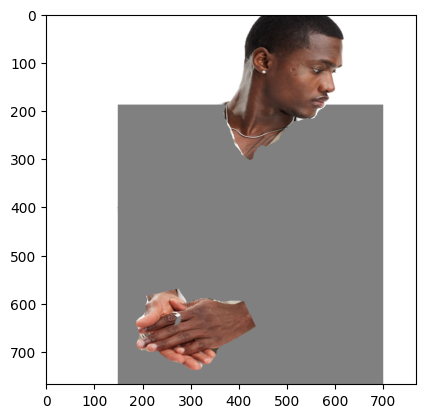

In [12]:
from matplotlib import pyplot as plt
plt.imshow(xxxxx)

In [108]:
np.unique(person_image_hp)

array([ 0,  2,  4,  7, 11, 14, 15])

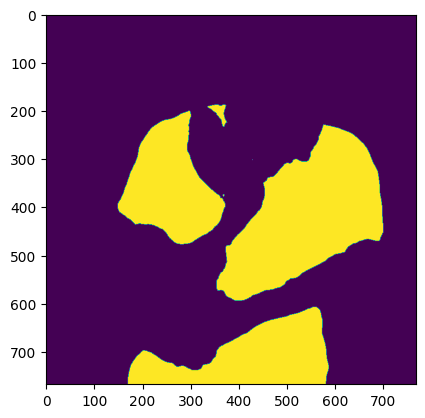

In [109]:
plt.imshow(person_image_hp==7)

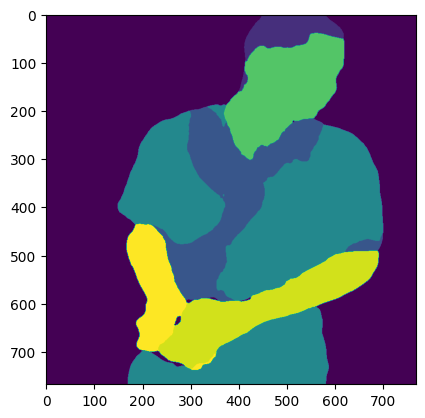

In [111]:
plt.imshow(person_image_hp)

(768, 768, 3)